In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
!pip install geopandas mapclassify folium -q

In [15]:
import geopandas as gpd
import pandas as pd

# Load Dataset 1 - Development Activity Model Footprints
footprints = gpd.read_file('/content/drive/MyDrive/Colab Notebooks/MOP/GreenRooftopPolygonLayers')

# Load Dataset 2 - Solar Rooftop Suitability
solar = gpd.read_file('/content/drive/MyDrive/Colab Notebooks/MOP/development-activity-model-footprints.geojson')

# Quick check
print("=== Development Activity Model Footprints ===")
print(f"Rows: {len(footprints)}")
print(f"Columns: {list(footprints.columns)}")
print(f"CRS: {footprints.crs}")
print()
print("=== Solar Rooftop Suitability ===")
print(f"Rows: {len(solar)}")
print(f"Columns: {list(solar.columns)}")
print(f"CRS: {solar.crs}")

=== Development Activity Model Footprints ===
Rows: 119530
Columns: ['Shape_Leng', 'Shape_Area', 'RATING', 'geometry']
CRS: EPSG:28355

=== Solar Rooftop Suitability ===
Rows: 1274
Columns: ['dev_key', 'status', 'permit_num', 'bldhgt_ahd', 'base_ahd', 'address', 'num_floors', 'land_use_1', 'land_use_2', 'land_use_3', 'shape_type', 'datadate', 'geo_point_2d', 'geometry']
CRS: EPSG:4326


In [16]:
# Swap the variable names - they loaded in reverse
solar_gdf = footprints.copy()    # this is actually the solar data
footprints_gdf = solar.copy()    # this is actually the footprints data

# Confirm they are correct now
print("=== Solar Rooftop - Columns ===")
print(list(solar_gdf.columns))
print(f"Rows: {len(solar_gdf)}")
print(f"CRS: {solar_gdf.crs}")
print()
print("=== Development Footprints - Columns ===")
print(list(footprints_gdf.columns))
print(f"Rows: {len(footprints_gdf)}")
print(f"CRS: {footprints_gdf.crs}")
print()

# Now check the RATING values
print("=== Solar RATING unique values ===")
print(solar_gdf['RATING'].value_counts())
print()

# Check STATUS values in footprints
print("=== Footprints STATUS unique values ===")
print(footprints_gdf['status'].value_counts())

=== Solar Rooftop - Columns ===
['Shape_Leng', 'Shape_Area', 'RATING', 'geometry']
Rows: 119530
CRS: EPSG:28355

=== Development Footprints - Columns ===
['dev_key', 'status', 'permit_num', 'bldhgt_ahd', 'base_ahd', 'address', 'num_floors', 'land_use_1', 'land_use_2', 'land_use_3', 'shape_type', 'datadate', 'geo_point_2d', 'geometry']
Rows: 1274
CRS: EPSG:4326

=== Solar RATING unique values ===
RATING
Good         49666
Moderate     22772
Poor         20883
Excellent    18195
Very Poor     8014
Name: count, dtype: int64

=== Footprints STATUS unique values ===
status
COMPLETED             554
APPROVED              450
UNDER CONSTRUCTION    139
APPLIED               131
Name: count, dtype: int64


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# STEP 1 - CLEAN SOLAR DATASET
# ============================================================

print("--- Cleaning Solar Dataset ---")

# Check for nulls
print(f"Nulls before cleaning:\n{solar_gdf.isnull().sum()}")

# Drop rows with missing RATING or geometry
solar_clean = solar_gdf.dropna(subset=['RATING', 'geometry', 'Shape_Area'])

# Remove zero or negative areas
solar_clean = solar_clean[solar_clean['Shape_Area'] > 0]

# Calculate usable rooftop area (75% efficiency factor)
solar_clean = solar_clean.copy()
solar_clean['usable_area_m2'] = solar_clean['Shape_Area'] * 0.75

# Map RATING to numeric score for calculations
rating_map = {
    'Excellent': 1.0,
    'Good':      0.75,
    'Moderate':  0.5,
    'Poor':      0.25,
    'Very Poor': 0.1
}
solar_clean['rating_score'] = solar_clean['RATING'].map(rating_map)

# Calculate estimated annual kWh
# Formula: usable_area x panel_efficiency(15%) x peak_sun_hours(4.5) x days(365)
solar_clean['est_kwh_year'] = (
    solar_clean['usable_area_m2'] *
    solar_clean['rating_score'] *
    0.15 *
    4.5 *
    365
)

print(f"\nRows after cleaning: {len(solar_clean)}")
print(f"Nulls after cleaning:\n{solar_clean.isnull().sum()}")
print(f"\nSample of cleaned solar data:")
print(solar_clean[['Shape_Area', 'usable_area_m2', 'RATING', 'rating_score', 'est_kwh_year']].head())

# ============================================================
# STEP 2 - CLEAN FOOTPRINTS DATASET
# ============================================================

print("\n--- Cleaning Footprints Dataset ---")

# Check nulls
print(f"Nulls before cleaning:\n{footprints_gdf.isnull().sum()}")

# Keep only relevant columns
cols_to_keep = ['dev_key', 'status', 'bldhgt_ahd', 'base_ahd',
                'address', 'num_floors', 'land_use_1',
                'shape_type', 'geometry']
footprints_clean = footprints_gdf[cols_to_keep].copy()

# Filter to COMPLETED and UNDER CONSTRUCTION only (most actionable)
footprints_clean = footprints_clean[
    footprints_clean['status'].isin(['COMPLETED', 'UNDER CONSTRUCTION'])
]

print(f"\nRows after filtering to COMPLETED + UNDER CONSTRUCTION: {len(footprints_clean)}")
print(f"\nStatus breakdown:\n{footprints_clean['status'].value_counts()}")

# ============================================================
# STEP 3 - ALIGN CRS BEFORE SPATIAL JOIN
# ============================================================

print("\n--- Aligning CRS ---")
print(f"Solar CRS: {solar_clean.crs}")
print(f"Footprints CRS: {footprints_clean.crs}")

# Convert footprints to match solar CRS (EPSG:28355)
footprints_projected = footprints_clean.to_crs(solar_clean.crs)
print(f"Footprints CRS after conversion: {footprints_projected.crs}")
print("\nCRS aligned successfully!")

--- Cleaning Solar Dataset ---
Nulls before cleaning:
Shape_Leng    0
Shape_Area    0
RATING        0
geometry      0
dtype: int64

Rows after cleaning: 119530
Nulls after cleaning:
Shape_Leng        0
Shape_Area        0
RATING            0
geometry          0
usable_area_m2    0
rating_score      0
est_kwh_year      0
dtype: int64

Sample of cleaned solar data:
   Shape_Area  usable_area_m2     RATING  rating_score  est_kwh_year
0        92.0            69.0  Excellent          1.00  16999.875002
1         8.0             6.0       Good          0.75   1108.687500
2        64.0            48.0       Good          0.75   8869.500001
3       100.0            75.0  Excellent          1.00  18478.124997
4         4.0             3.0       Good          0.75    554.343750

--- Cleaning Footprints Dataset ---
Nulls before cleaning:
dev_key           0
status            0
permit_num        0
bldhgt_ahd        0
base_ahd          0
address           0
num_floors        0
land_use_1       14


In [18]:
import matplotlib.pyplot as plt

# ============================================================
# STEP 4 - SPATIAL JOIN
# ============================================================

print("--- Performing Spatial Join ---")

# Join solar rooftops that fall within building footprints
joined = gpd.sjoin(
    solar_clean,
    footprints_projected[['dev_key', 'status', 'address',
                           'bldhgt_ahd', 'num_floors',
                           'land_use_1', 'shape_type', 'geometry']],
    how='inner',
    predicate='intersects'
)

print(f"Matched rooftops: {len(joined)}")
print(f"Columns: {list(joined.columns)}")
print()

# ============================================================
# STEP 5 - AGGREGATE BY BUILDING
# ============================================================

print("--- Aggregating by Building ---")

building_summary = joined.groupby(['dev_key', 'address', 'status',
                                    'bldhgt_ahd', 'num_floors',
                                    'land_use_1', 'shape_type']).agg(
    total_rooftop_area_m2  = ('Shape_Area', 'sum'),
    usable_area_m2         = ('usable_area_m2', 'sum'),
    avg_rating_score       = ('rating_score', 'mean'),
    dominant_rating        = ('RATING', lambda x: x.value_counts().index[0]),
    est_kwh_year           = ('est_kwh_year', 'sum'),
    rooftop_count          = ('RATING', 'count')
).reset_index()

# Convert kWh to MWh for readability
building_summary['est_mwh_year'] = (building_summary['est_kwh_year'] / 1000).round(2)

# Rank by solar generation potential
building_summary = building_summary.sort_values('est_kwh_year', ascending=False).reset_index(drop=True)
building_summary['rank'] = building_summary.index + 1

print(f"Total buildings with solar data: {len(building_summary)}")
print()

# ============================================================
# STEP 6 - KEY STATS
# ============================================================

print("=== KEY FINDINGS ===")
print(f"Total matched rooftops:         {len(joined):,}")
print(f"Total buildings analysed:       {len(building_summary):,}")
print(f"Total usable rooftop area:      {building_summary['usable_area_m2'].sum():,.0f} m²")
print(f"Total estimated generation:     {building_summary['est_mwh_year'].sum():,.0f} MWh/year")
print(f"Avg generation per building:    {building_summary['est_mwh_year'].mean():,.1f} MWh/year")
print()
print("--- Top 10 Buildings by Solar Potential ---")
print(building_summary[['rank', 'address', 'status', 'dominant_rating',
                          'usable_area_m2', 'est_mwh_year']].head(10).to_string(index=False))
print()
print("--- Under Construction Buildings (Priority Targets) ---")
uc = building_summary[building_summary['status'] == 'UNDER CONSTRUCTION']
print(f"Count: {len(uc)}")
print(uc[['rank', 'address', 'dominant_rating',
           'usable_area_m2', 'est_mwh_year']].head(10).to_string(index=False))

--- Performing Spatial Join ---
Matched rooftops: 9899
Columns: ['Shape_Leng', 'Shape_Area', 'RATING', 'geometry', 'usable_area_m2', 'rating_score', 'est_kwh_year', 'index_right', 'dev_key', 'status', 'address', 'bldhgt_ahd', 'num_floors', 'land_use_1', 'shape_type']

--- Aggregating by Building ---
Total buildings with solar data: 559

=== KEY FINDINGS ===
Total matched rooftops:         9,899
Total buildings analysed:       559
Total usable rooftop area:      913,395 m²
Total estimated generation:     191,956 MWh/year
Avg generation per building:    343.4 MWh/year

--- Top 10 Buildings by Solar Potential ---
 rank                                                                           address             status dominant_rating  usable_area_m2  est_mwh_year
    1                                           130-188 Todd Road, Port Melbourne, 3207 UNDER CONSTRUCTION            Good         26685.0       6476.77
    2                                         263-283 Spencer Street DOCKLAN

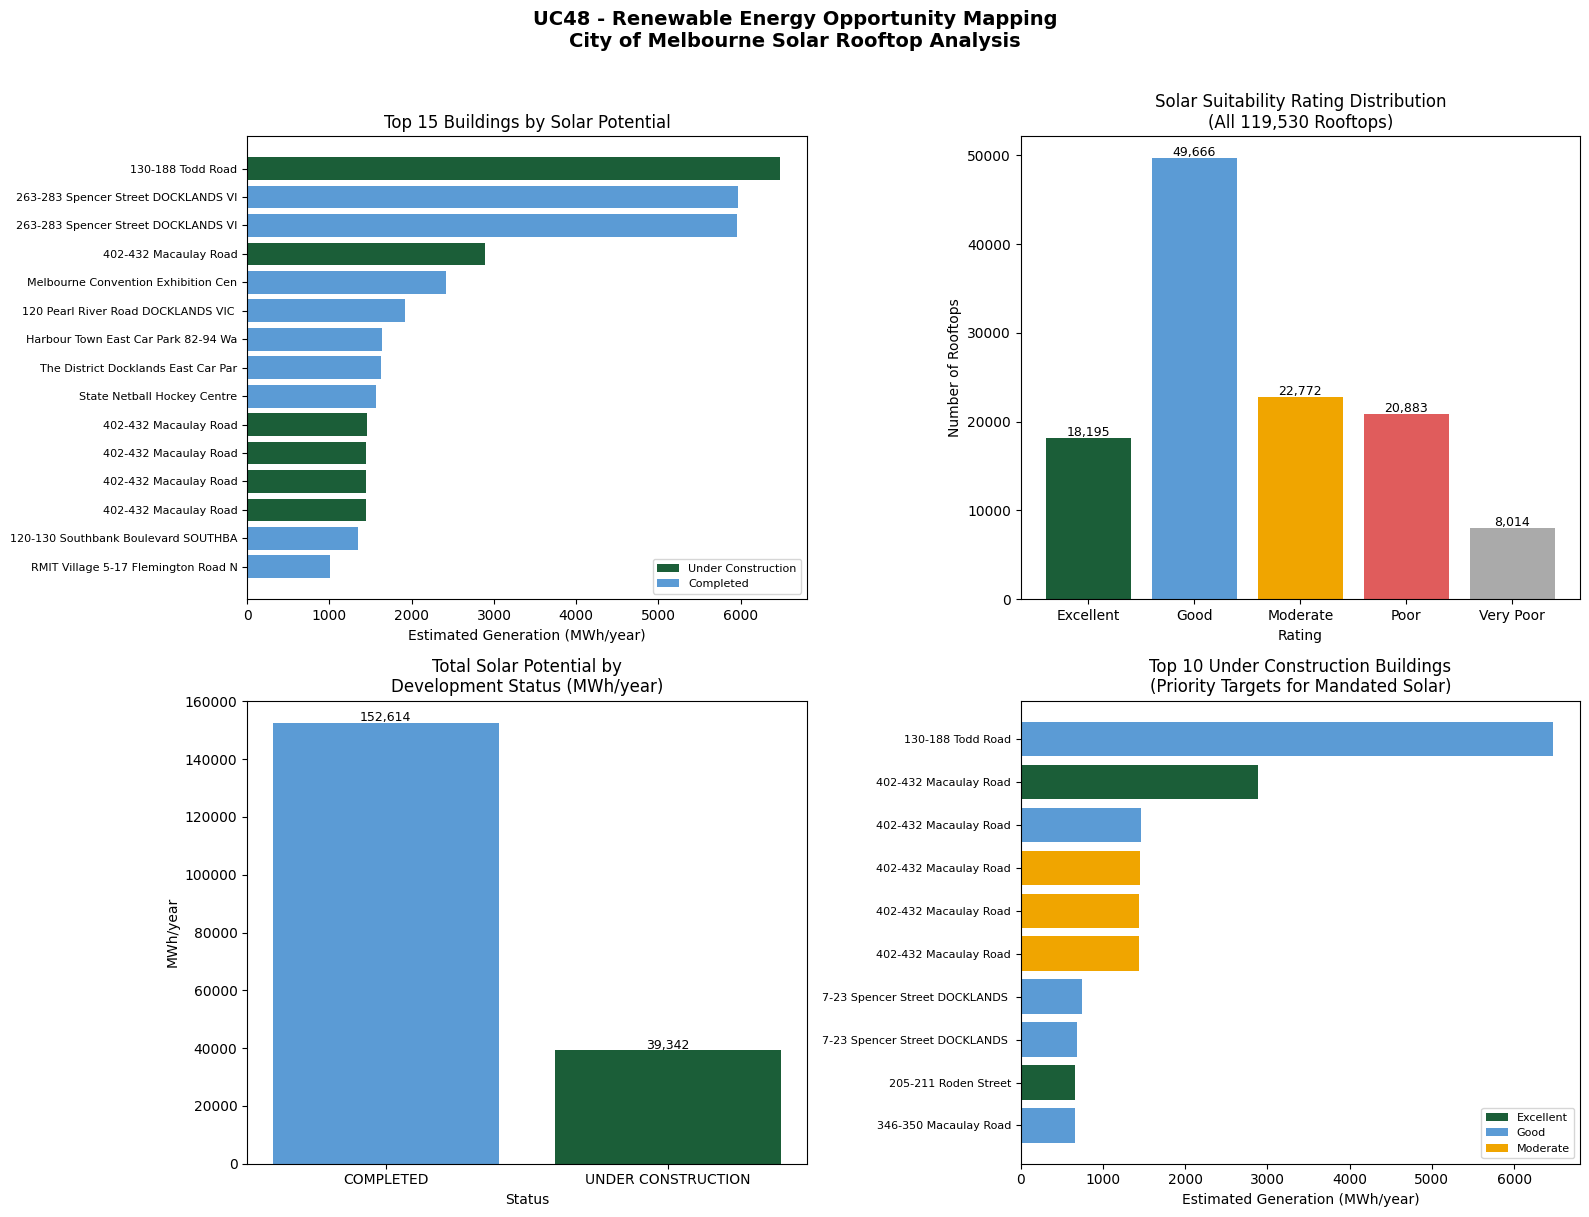

Charts saved to Google Drive!


In [22]:
# ============================================================
# STEP 7 - VISUALISATIONS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('UC48 - Renewable Energy Opportunity Mapping\nCity of Melbourne Solar Rooftop Analysis',
             fontsize=14, fontweight='bold', y=1.01)

# --- Chart 1: Top 15 Buildings by Solar Potential ---
ax1 = axes[0, 0]
top15 = building_summary.head(15).copy()
top15['short_address'] = top15['address'].str.split(',').str[0].str[:35]
colors = ['#1B5E38' if s == 'UNDER CONSTRUCTION' else '#5B9BD5'
          for s in top15['status']]
bars = ax1.barh(range(len(top15)), top15['est_mwh_year'], color=colors)
ax1.set_yticks(range(len(top15)))
ax1.set_yticklabels(top15['short_address'], fontsize=8)
ax1.invert_yaxis()
ax1.set_xlabel('Estimated Generation (MWh/year)')
ax1.set_title('Top 15 Buildings by Solar Potential')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#1B5E38', label='Under Construction'),
                   Patch(facecolor='#5B9BD5', label='Completed')]
ax1.legend(handles=legend_elements, fontsize=8)

# --- Chart 2: Solar Rating Distribution ---
ax2 = axes[0, 1]
rating_order = ['Excellent', 'Good', 'Moderate', 'Poor', 'Very Poor']
rating_colors = ['#1B5E38', '#5B9BD5', '#F0A500', '#E05C5C', '#AAAAAA']
rating_counts = solar_clean['RATING'].value_counts().reindex(rating_order)
ax2.bar(rating_order, rating_counts.values, color=rating_colors)
ax2.set_title('Solar Suitability Rating Distribution\n(All 119,530 Rooftops)')
ax2.set_xlabel('Rating')
ax2.set_ylabel('Number of Rooftops')
for i, v in enumerate(rating_counts.values):
    ax2.text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

# --- Chart 3: MWh potential by Status ---
ax3 = axes[1, 0]
status_energy = building_summary.groupby('status')['est_mwh_year'].sum()
status_colors = ['#1B5E38' if s == 'UNDER CONSTRUCTION' else '#5B9BD5'
                 for s in status_energy.index]
ax3.bar(status_energy.index, status_energy.values, color=status_colors)
ax3.set_title('Total Solar Potential by\nDevelopment Status (MWh/year)')
ax3.set_xlabel('Status')
ax3.set_ylabel('MWh/year')
for i, v in enumerate(status_energy.values):
    ax3.text(i, v + 500, f'{v:,.0f}', ha='center', fontsize=9)

# --- Chart 4: Top 10 Under Construction ---
ax4 = axes[1, 1]
uc_top10 = uc.head(10).copy()
uc_top10['short_address'] = uc_top10['address'].str.split(',').str[0].str[:30]
uc_colors = ['#1B5E38' if r == 'Excellent' else
             '#5B9BD5' if r == 'Good' else '#F0A500'
             for r in uc_top10['dominant_rating']]
ax4.barh(range(len(uc_top10)), uc_top10['est_mwh_year'], color=uc_colors)
ax4.set_yticks(range(len(uc_top10)))
ax4.set_yticklabels(uc_top10['short_address'], fontsize=8)
ax4.invert_yaxis()
ax4.set_xlabel('Estimated Generation (MWh/year)')
ax4.set_title('Top 10 Under Construction Buildings\n(Priority Targets for Mandated Solar)')
legend_uc = [Patch(facecolor='#1B5E38', label='Excellent'),
             Patch(facecolor='#5B9BD5', label='Good'),
             Patch(facecolor='#F0A500', label='Moderate')]
ax4.legend(handles=legend_uc, fontsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/MOP/solar_analysis_charts.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved to Google Drive!")

In [23]:
# ============================================================
# STEP 8 - INTERACTIVE FOLIUM MAP
# ============================================================

import folium
from folium.plugins import MarkerCluster
import json

# Convert building_summary back to GeoDataFrame for mapping
# Use footprints_projected geometry for the map
map_data = footprints_projected.merge(
    building_summary[['dev_key', 'dominant_rating', 'est_mwh_year',
                       'usable_area_m2', 'avg_rating_score', 'rank', 'status']],
    on='dev_key',
    how='inner'
)

# Convert to WGS84 (lat/lon) for folium
map_data_wgs = map_data.to_crs(epsg=4326)

# Colour mapping
def get_color(rating):
    return {
        'Excellent': '#1B5E38',
        'Good':      '#5B9BD5',
        'Moderate':  '#F0A500',
        'Poor':      '#E05C5C',
        'Very Poor': '#AAAAAA'
    }.get(rating, '#AAAAAA')

def get_status_icon(status):
    return '🏗️' if status == 'UNDER CONSTRUCTION' else '🏢'

# Create map centred on Melbourne
m = folium.Map(
    location=[-37.813, 144.963],
    zoom_start=13,
    tiles='CartoDB positron'
)

# Add title
title_html = '''
<div style="position: fixed; top: 10px; left: 50%; transform: translateX(-50%);
     z-index: 1000; background: white; padding: 10px 20px;
     border-radius: 8px; border: 2px solid #1B5E38;
     font-family: Arial; font-size: 14px; font-weight: bold; text-align: center;
     box-shadow: 2px 2px 6px rgba(0,0,0,0.3);">
     UC48 — Solar Rooftop Opportunity Map<br>
     <span style="font-size:11px; font-weight:normal; color:#555;">
     City of Melbourne | 559 Buildings Analysed
     </span>
</div>
'''
m.get_root().html.add_child(folium.Element(title_html))

# Add legend
legend_html = '''
<div style="position: fixed; bottom: 30px; left: 20px; z-index: 1000;
     background: white; padding: 12px 16px; border-radius: 8px;
     border: 1px solid #ccc; font-family: Arial; font-size: 12px;
     box-shadow: 2px 2px 6px rgba(0,0,0,0.2);">
     <b>Solar Suitability</b><br>
     <span style="color:#1B5E38">&#9632;</span> Excellent<br>
     <span style="color:#5B9BD5">&#9632;</span> Good<br>
     <span style="color:#F0A500">&#9632;</span> Moderate<br>
     <span style="color:#E05C5C">&#9632;</span> Poor<br>
     <span style="color:#AAAAAA">&#9632;</span> Very Poor<br>
     <hr style="margin:6px 0">
     <b>Status</b><br>
     🏗️ Under Construction<br>
     🏢 Completed
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

# Plot each building as a polygon
for _, row in map_data_wgs.iterrows():
    if row.geometry is None:
        continue

    color = get_color(row['dominant_rating'])
    icon  = get_status_icon(row['status_x'])

    popup_html = f"""
    <div style="font-family:Arial; font-size:12px; width:220px">
        <b>{icon} {row['address']}</b><br>
        <hr style="margin:4px 0">
        <b>Status:</b> {row['status_x']}<br>
        <b>Solar Rating:</b> {row['dominant_rating']}<br>
        <b>Usable Area:</b> {row['usable_area_m2']:,.0f} m²<br>
        <b>Est. Generation:</b> {row['est_mwh_year']:,.1f} MWh/yr<br>
        <b>Overall Rank:</b> #{int(row['rank'])}
    </div>
    """

    folium.GeoJson(
        row.geometry.__geo_interface__,
        style_function=lambda x, c=color: {
            'fillColor': c,
            'color': c,
            'weight': 1.5,
            'fillOpacity': 0.7
        },
        tooltip=f"{row['address'][:40]} | {row['dominant_rating']} | {row['est_mwh_year']:,.0f} MWh/yr",
        popup=folium.Popup(popup_html, max_width=240)
    ).add_to(m)

# Save map
map_path = '/content/drive/MyDrive/Colab Notebooks/MOP/solar_opportunity_map.html'
m.save(map_path)
print(f"Map saved to Google Drive!")
print(f"Buildings plotted: {len(map_data_wgs)}")
print(f"\nOpen solar_opportunity_map.html from your Drive to view the interactive map!")

Map saved to Google Drive!
Buildings plotted: 1232

Open solar_opportunity_map.html from your Drive to view the interactive map!
